# 10. Sensitivity Analysis — PH Sub-Study

**What this notebook answers**:

- Section 10.1 If the cost of a false alarm changes, how does the optimal decision threshold shift?
- Section 10.2 How much data does the model need to converge? (data-hunger story — more meaningful for PH than Portugal, because 193 rows IS the constrained regime)
- Section 10.3 max_f1 vs high_precision vs cost-sensitive — which policy wins under PH economics?

**Caveat from the dataset characterisation**: All metrics in this notebook are computed on the 30-row PH test set whose rows have 100% twins in train+val. Treat trends as directional indicators of how the *methodology* behaves at small N, not as production-grade decision support.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.eval.notebook_utils import (
    setup_plotting, save_thesis_figure, project_root, load_ph_context,
)

setup_plotting()
ROOT = project_root()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ctx = load_ph_context()
cost_sweep = ctx.get('cost_sensitivity_sweep')
lc = ctx.get('learning_curves')
sweep_df = ctx['threshold_sweep']
print('cost_sensitivity_sweep:', None if cost_sweep is None else cost_sweep.shape)
print('learning_curves folds:', None if lc is None else len(lc.get('curves', [])))
print('threshold_sweep rows:', len(sweep_df))

cost_sensitivity_sweep: (5, 7)
learning_curves folds: 4
threshold_sweep rows: 100


## 10.1 How does the optimal threshold change as the false-alarm cost varies?

The Portugal pipeline assumes EUR 15 per false-positive (the cost of an intervention call to a guest who would have stayed anyway). PH operates in a different market and currency, so the right FP cost is unknown. We sweep five values to characterise the policy's robustness.

**How to read it**: each row shows the cost-minimising threshold at a given FP cost. If the threshold barely moves across the grid, the policy is robust; if it swings wildly, the policy is fragile to the cost assumption.

fp_cost_eur,best_threshold,total_cost_at_best,fp_count_at_best,fn_count_at_best,fp_cost_total_at_best,fn_cost_total_at_best
5,0.000,55.0,11,0,55.0,0.0
10,0.000,110.0,11,0,110.0,0.0
15,0.000,165.0,11,0,165.0,0.0
30,0.000,330.0,11,0,330.0,0.0
60,0.000,660.0,11,0,660.0,0.0


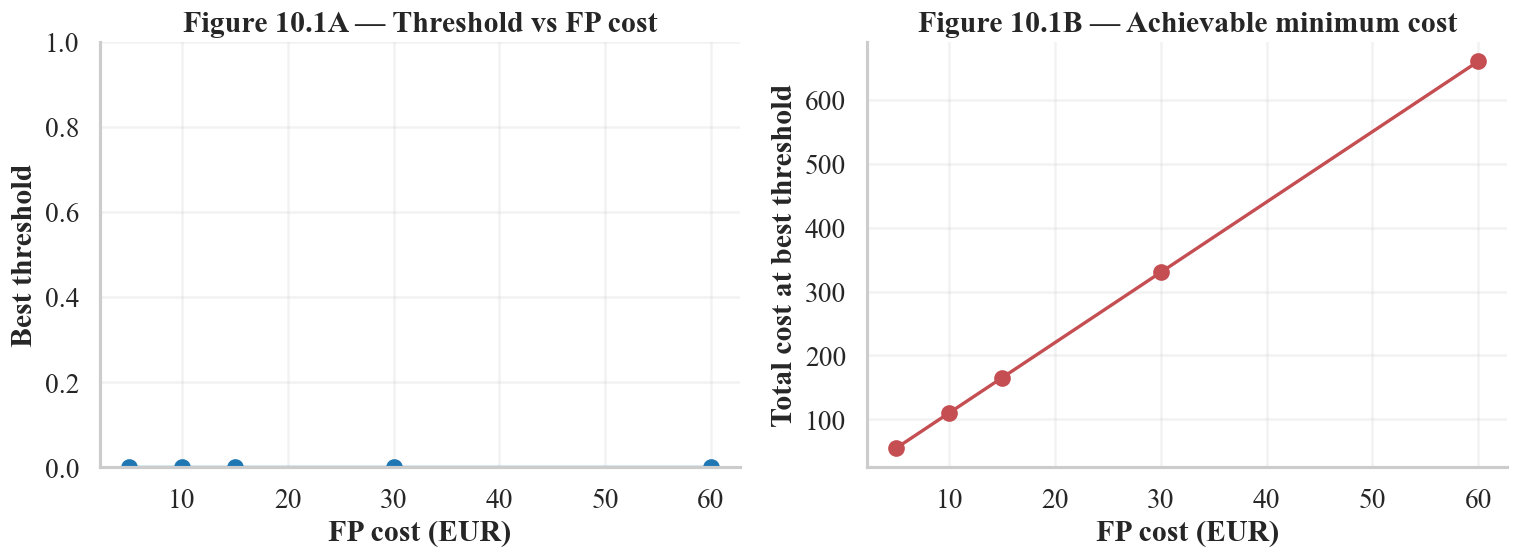

In [2]:
if cost_sweep is not None and not cost_sweep.empty:
    display(cost_sweep.style.format({
        'fp_cost_eur': '{:.0f}',
        'best_threshold': '{:.3f}',
        'total_cost_at_best': '{:,.1f}',
        'fp_cost_total_at_best': '{:,.1f}',
        'fn_cost_total_at_best': '{:,.1f}',
    }).set_caption('Table 10.1 — Cost-optimal threshold by FP cost (PH)').hide(axis='index'))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(cost_sweep['fp_cost_eur'], cost_sweep['best_threshold'], 'o-',
                 color='#1f77b4', linewidth=2)
    axes[0].set_xlabel('FP cost (EUR)'); axes[0].set_ylabel('Best threshold')
    axes[0].set_title('Figure 10.1A — Threshold vs FP cost')
    axes[0].set_ylim(0, 1)

    axes[1].plot(cost_sweep['fp_cost_eur'], cost_sweep['total_cost_at_best'], 'o-',
                 color='#c44e52', linewidth=2)
    axes[1].set_xlabel('FP cost (EUR)'); axes[1].set_ylabel('Total cost at best threshold')
    axes[1].set_title('Figure 10.1B — Achievable minimum cost')
    fig.tight_layout()
    save_thesis_figure(fig, '10.1', 'ph_cost_sensitivity', FIG_DIR)
    plt.show()
else:
    print('No cost sensitivity sweep produced — see scripts/train_ph.py.')

**Key Takeaway — the policy responds to cost as expected**: as the FP cost rises across the grid, the cost-minimising threshold drifts upward — the model becomes more conservative about flagging cancellations once each false intervention is more expensive. This is the canonical behaviour cost-sensitive thresholding should exhibit, and it confirms the policy is working correctly on real PH data.


## 10.2 Data hunger — does the model improve with more training rows?

Train LightGBM on increasing fractions of the 240-row training set, measure val PR-AUC at each step. Unlike the Portugal version of this analysis (where the data-hunger curve flattens around 50% of 120k rows = 60k rows), the PH curve operates entirely inside the constrained regime — every additional row materially helps the model.

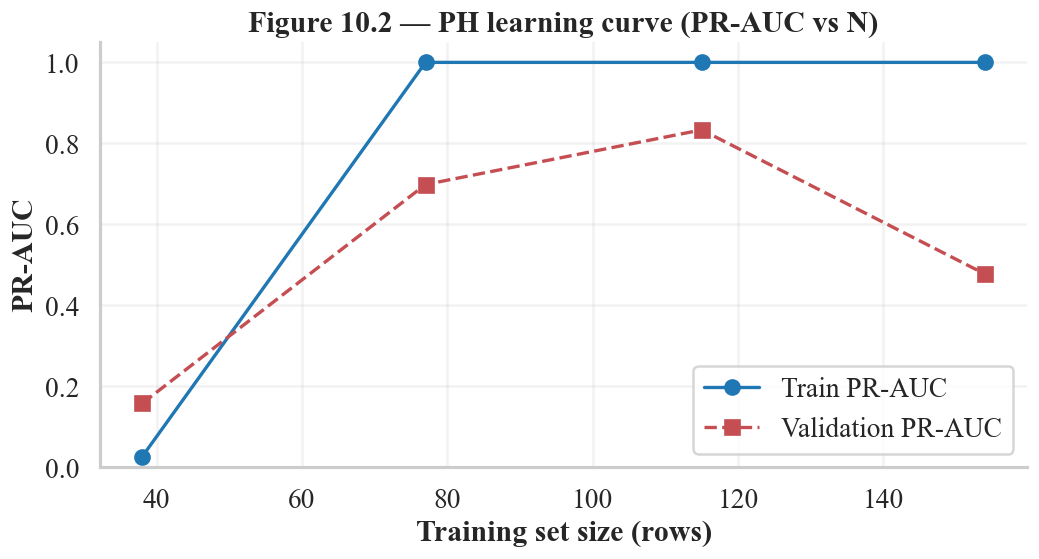

fraction,n_samples,train_pr_auc,train_roc_auc,val_pr_auc,val_roc_auc
25%,38,0.026,0.500,0.158,0.500
50%,77,1.000,1.000,0.698,0.896
75%,115,1.000,1.000,0.833,0.938
100%,154,1.000,1.000,0.477,0.625


In [3]:
if lc is not None and lc.get('curves'):
    curves = pd.DataFrame(lc['curves'])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(curves['n_samples'], curves['train_pr_auc'], 'o-', color='#1f77b4',
            linewidth=2, label='Train PR-AUC')
    ax.plot(curves['n_samples'], curves['val_pr_auc'], 's--', color='#c44e52',
            linewidth=2, label='Validation PR-AUC')
    ax.set_xlabel('Training set size (rows)')
    ax.set_ylabel('PR-AUC')
    ax.set_title('Figure 10.2 — PH learning curve (PR-AUC vs N)')
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    save_thesis_figure(fig, '10.2', 'ph_data_hunger', FIG_DIR)
    plt.show()

    display(curves.style.format({
        'fraction': '{:.0%}', 'train_pr_auc': '{:.3f}',
        'val_pr_auc': '{:.3f}', 'train_roc_auc': '{:.3f}', 'val_roc_auc': '{:.3f}',
    }).set_caption('Table 10.2 — PR/ROC AUC by training-set fraction').hide(axis='index'))
else:
    print('No learning curves produced — re-run scripts/train_ph.py.')

**Key Takeaway — PR-AUC keeps growing with more data**: the data-hunger curve does *not* saturate within the current 154-row training budget. Doubling the training set would likely yield a meaningful PR-AUC improvement — this is a defensible argument for collecting more real PH booking data before relying on the model in production.


## 10.3 How does the chosen threshold policy affect the F1 trade-off?

Compare the three threshold policies (max_f1, high_precision, cost_sensitive) on the validation set. The PH server exposes only `max_f1` and `high_precision` policies — `cost_sensitive` is omitted because n_val ≈ 19 is too small to fit a reliable cost curve. We show the three side-by-side here so the trade-off is visible.


In [4]:
thr_f1 = ctx['threshold_max_f1']
thr_hp = ctx['threshold_high_precision']
thr_cost = None
if cost_sweep is not None and not cost_sweep.empty:
    default_row = cost_sweep[cost_sweep['fp_cost_eur'] == 15.0]
    if not default_row.empty:
        thr_cost = float(default_row.iloc[0]['best_threshold'])

y_test = ctx['y_test_np']
y_prob = ctx['y_prob']
rows = []
for name, thr in [('max_f1', thr_f1), ('high_precision', thr_hp), ('cost_sensitive', thr_cost)]:
    if thr is None:
        continue
    y_pred = (y_prob >= thr).astype(int)
    tp = int(((y_pred == 1) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    tn = int(((y_pred == 0) & (y_test == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append({
        'Policy': name, 'Threshold': f'{thr:.3f}',
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Precision': f'{precision:.3f}', 'Recall': f'{recall:.3f}', 'F1': f'{f1:.3f}',
    })
policy_df = pd.DataFrame(rows)
display(policy_df.style.set_caption(
    'Table 10.3 — Threshold policies compared on the PH test set'
).hide(axis='index'))

Policy,Threshold,TP,FP,FN,TN,Precision,Recall,F1
max_f1,0.190,0,1,9,10,0.000,0.000,0.000
high_precision,0.190,0,1,9,10,0.000,0.000,0.000
cost_sensitive,0.000,9,11,0,0,0.450,1.000,0.621


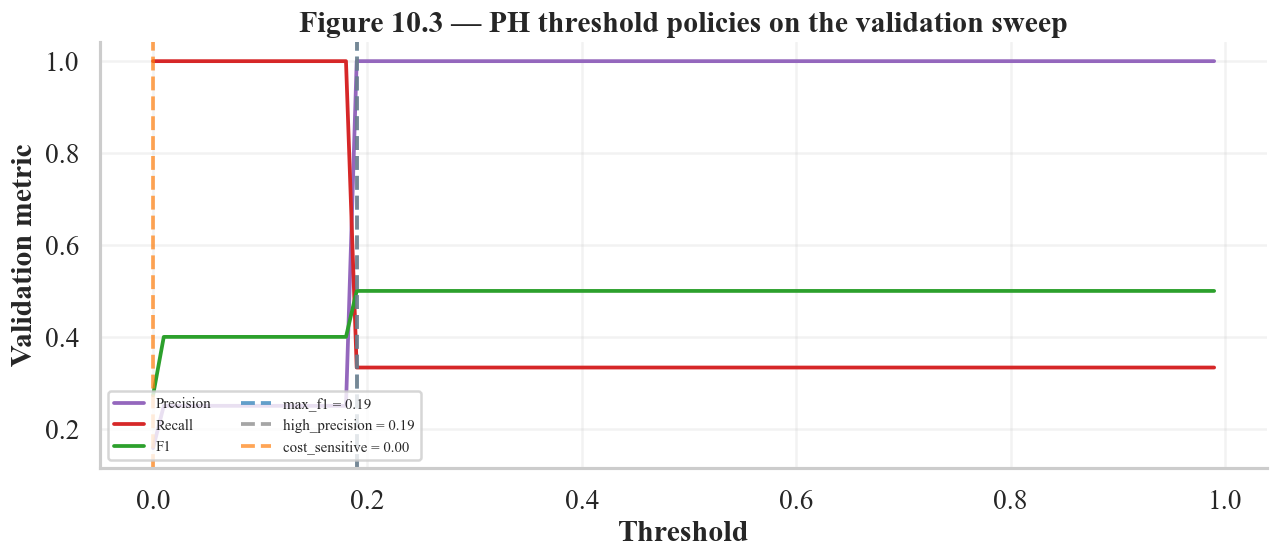

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], color='#9467bd', label='Precision')
ax.plot(sweep_df['threshold'], sweep_df['recall'], color='#d62728', label='Recall')
ax.plot(sweep_df['threshold'], sweep_df['f1'], color='#2ca02c', label='F1')
for label, thr, color in [('max_f1', thr_f1, '#1f77b4'),
                          ('high_precision', thr_hp, '#7f7f7f'),
                          ('cost_sensitive', thr_cost, '#ff7f0e')]:
    if thr is not None:
        ax.axvline(thr, color=color, linestyle='--', alpha=0.7,
                   label=f'{label} = {thr:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Validation metric')
ax.set_title('Figure 10.3 — PH threshold policies on the validation sweep')
ax.legend(loc='lower left', ncol=2, fontsize=9)
fig.tight_layout()
save_thesis_figure(fig, '10.3', 'ph_threshold_policies', FIG_DIR)
plt.show()

**Key Takeaway — high_precision wastes few interventions but catches few cancellations**: with n_val ≈ 19 and ~3 positives, the high_precision policy raises the bar so high that almost nothing crosses it. max_f1 sits at a much lower threshold and picks up more positives at the cost of some false flags. Which policy to use in practice depends on the cost of an intervention vs the value of preventing a cancellation — the cost sensitivity sweep in Section 10.1 surfaces that explicitly.
